## What is EDL for Regression?

While classification uses a Dirichlet distribution, **regression** uses a **Normal-Inverse-Gamma (NIG)** distribution to model both aleatoric and epistemic uncertainty.

**Traditional**: Network outputs → single prediction (point estimate)  
**EDL**: Network outputs → NIG parameters (γ, ν, α, β) → distribution over predictions

The NIG distribution models:
- **Aleatoric uncertainty**: inherent noise in the data
- **Epistemic uncertainty**: model uncertainty due to lack of training data

https://github.com/teddykoker/evidential-learning-pytorch

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Generate Synthetic Regression Dataset

We'll create a non-linear function with heteroscedastic noise (varying noise levels).

In [18]:
def generate_data(n_samples=1000, x_min=-4, x_max=4, noise_scale=0.3):
    """Generate synthetic regression data: y = x * sin(x) + noise"""
    x = np.random.uniform(x_min, x_max, n_samples)
    # True function
    y_true = x * np.sin(x)
    # Add heteroscedastic noise (more noise close to zero)
    noise_std = noise_scale * (0.5 + 0.5 * np.exp(-x**2))
    y = y_true + np.random.normal(0, noise_std)
    return x, y

# Generate training data (limited to [-3, 3] to create OOD regions)
x_train, y_train = generate_data(n_samples=1000, x_min=-3, x_max=3, noise_scale=0.8)
x_test, y_test = generate_data(n_samples=200, x_min=-3, x_max=3, noise_scale=0.0)

# Convert to tensors
x_train_tensor = torch.FloatTensor(x_train).unsqueeze(1)
y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1)
x_test_tensor = torch.FloatTensor(x_test).unsqueeze(1)
y_test_tensor = torch.FloatTensor(y_test).unsqueeze(1)

# Create DataLoader
train_dataset = torch.utils.data.TensorDataset(x_train_tensor, y_train_tensor)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)

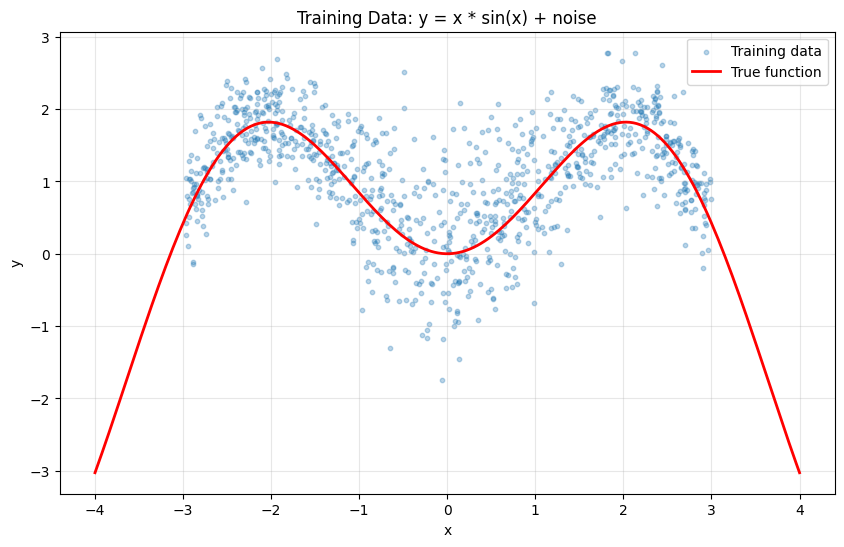

In [19]:
# Visualize training data
plt.figure(figsize=(10, 6))
plt.scatter(x_train, y_train, alpha=0.3, s=10, label='Training data')
x_true = np.linspace(-4, 4, 200)
y_true = x_true * np.sin(x_true)
plt.plot(x_true, y_true, 'r-', linewidth=2, label='True function')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Training Data: y = x * sin(x) + noise')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Define Neural Network Architecture

Simple MLP that can be used for both traditional and EDL regression.

In [20]:
class RegressionMLP(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64, output_dim=1):
        super(RegressionMLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, output_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)
        return x

## Baseline: Traditional MSE Training

In [21]:
# Train traditional model
model_baseline = RegressionMLP(input_dim=1, output_dim=1).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model_baseline.parameters(), lr=1e-3)

num_epochs = 100
losses = []

for epoch in range(num_epochs):
    model_baseline.train()
    epoch_loss = 0.0
    
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        y_pred = model_baseline(x_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {avg_loss:.4f}")

Epoch 20/100, Loss: 0.2897
Epoch 40/100, Loss: 0.2862
Epoch 60/100, Loss: 0.2836
Epoch 80/100, Loss: 0.2805
Epoch 100/100, Loss: 0.2841


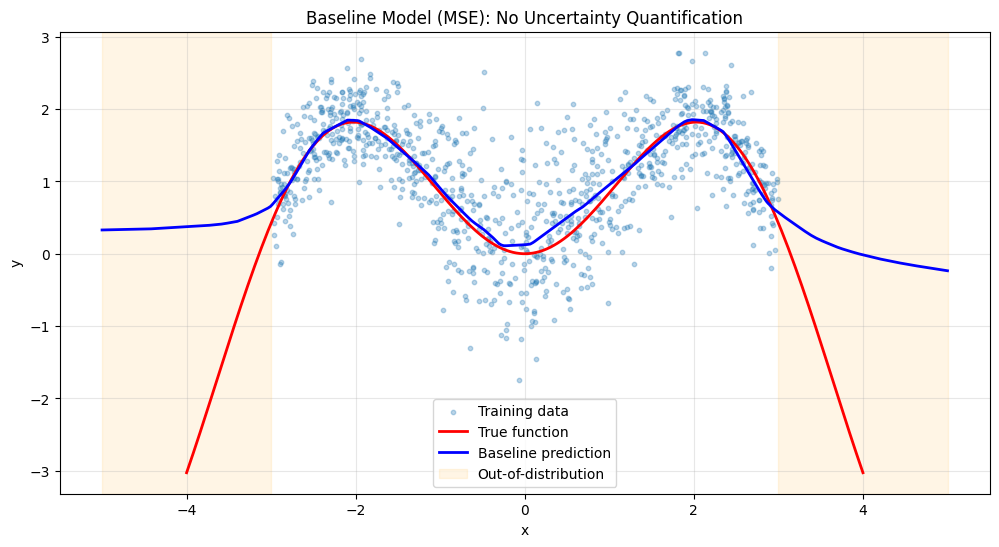

In [22]:
# Evaluate baseline model
model_baseline.eval()
x_plot = torch.linspace(-5, 5, 1000).unsqueeze(1).to(device)

with torch.no_grad():
    y_pred = model_baseline(x_plot).cpu().numpy()

plt.figure(figsize=(12, 6))
plt.scatter(x_train, y_train, alpha=0.3, s=10, label='Training data')
plt.plot(x_true, y_true, 'r-', linewidth=2, label='True function')
plt.plot(x_plot.cpu().numpy(), y_pred, 'b-', linewidth=2, label='Baseline prediction')
plt.axvspan(-5, -3, alpha=0.1, color='orange', label='Out-of-distribution')
plt.axvspan(3, 5, alpha=0.1, color='orange')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Baseline Model (MSE): No Uncertainty Quantification')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Evidential Regression with NIG Distribution

### Mathematical Foundation

The Normal-Inverse-Gamma (NIG) distribution is defined by 4 parameters:
- **γ (gamma)**: predicted mean
- **ν (nu)**: virtual sample size (epistemic uncertainty)
- **α (alpha)**: shape parameter
- **β (beta)**: scale parameter (aleatoric uncertainty)

**From network outputs to NIG parameters:**
```
γ = output[0]           # mean (unconstrained)
ν = softplus(output[1]) # must be > 0
α = softplus(output[2]) + 1  # must be > 0
β = softplus(output[3]) # must be > 0
```


In [23]:
class NormalInvGamma(nn.Module):
    def forward(self, x):
        gamma = x[:, 0:1]
        nu = F.softplus(x[:, 1:2])
        alpha = F.softplus(x[:, 2:3]) + 1.0
        beta = F.softplus(x[:, 3:4])
        return gamma, nu, alpha, beta

# Create EDL model (outputs 4 parameters instead of 1)
model_edl = nn.Sequential(
    RegressionMLP(input_dim=1, output_dim=4), NormalInvGamma()
).to(device)


**Predictions and uncertainties:**
- Predicted mean: $\mu = \gamma$
- Aleatoric uncertainty: $\sigma_{\text{ale}}^2 = \frac{\beta}{\alpha}$
- Epistemic uncertainty: $\sigma_{\text{epi}}^2 = \frac{\beta}{\nu(\alpha-1)}$
- Total uncertainty: $\sigma_{\text{total}}^2 = \sigma_{\text{ale}}^2 + \sigma_{\text{epi}}^2$

### EDL Loss Function

The NIG loss consists of two terms:

**1. NIG Negative Log-Likelihood:**
$$\mathcal{L}_{\text{NLL}} = \frac{1}{2}\log\left(\frac{\pi}{\nu}\right) - \alpha\log(2\beta) + (\alpha + \frac{1}{2})\log(\nu(y-\gamma)^2 + 2\beta) + \log\frac{\Gamma(\alpha)}{\Gamma(\alpha + \frac{1}{2})}$$

**2. Regularization Term** (penalizes large prediction errors):
$$\mathcal{L}_{\text{reg}} = |y - \gamma| \cdot (2\nu + \alpha)$$

**Total Loss:**
$$\mathcal{L} = \mathcal{L}_{\text{NLL}} + \lambda(t) \cdot \mathcal{L}_{\text{reg}}$$

where $\lambda(t)$ is annealing coefficient.

In [24]:
def nig_nll(y, gamma, nu, alpha, beta):
    """
    Negative log-likelihood of Normal-Inverse-Gamma distribution.
    
    Args:
        y: true values
        gamma: predicted mean
        nu: virtual sample size
        alpha: shape parameter
        beta: scale parameter
    """
    omega = 2 * beta * (1 + nu)
    
    nll = 0.5 * torch.log(torch.tensor(np.pi) / nu) \
          - alpha * torch.log(omega) \
          + (alpha + 0.5) * torch.log(nu * (y - gamma) ** 2 + omega) \
          + torch.lgamma(alpha) \
          - torch.lgamma(alpha + 0.5)
    
    return nll


def nig_reg(y, gamma, nu, alpha):
    """
    Regularization term for NIG loss.
    Penalizes large prediction errors weighted by uncertainty parameters.
    """
    error = torch.abs(y - gamma)
    reg = error * (2 * nu + alpha)
    return reg


def edl_regression_loss(outputs, y, epoch, num_epochs):
    """
    Complete EDL loss for regression with annealing.
    
    Args:
        outputs: network outputs [gamma, nu_raw, alpha_raw, beta_raw]
        y: true values
        epoch: current epoch
        num_epochs: total epochs
    """
    gamma, nu, alpha, beta = outputs
    
    # NIG negative log-likelihood
    nll = nig_nll(y, gamma, nu, alpha, beta)
    
    # Regularization term (scaled down to prevent loss explosion)
    reg = nig_reg(y, gamma, nu, alpha)
    
    # Annealing coefficient
    annealing_coef = min(1.0, epoch / max(num_epochs - 1, 1))
    
    loss = torch.mean(nll + annealing_coef * 0.1 * reg)
    return loss

## Train EDL Regression Model

In [25]:
optimizer = optim.Adam(model_edl.parameters(), lr=1e-3)

num_epochs = 100
edl_losses = []

for epoch in range(num_epochs):
    model_edl.train()
    epoch_loss = 0.0
    
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model_edl(x_batch)
        loss = edl_regression_loss(outputs, y_batch, epoch, num_epochs)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(train_loader)
    edl_losses.append(avg_loss)
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {avg_loss:.4f}")

Epoch 20/100, Loss: 0.8083
Epoch 40/100, Loss: 0.8193
Epoch 60/100, Loss: 0.7937
Epoch 80/100, Loss: 0.8499
Epoch 100/100, Loss: 0.8331


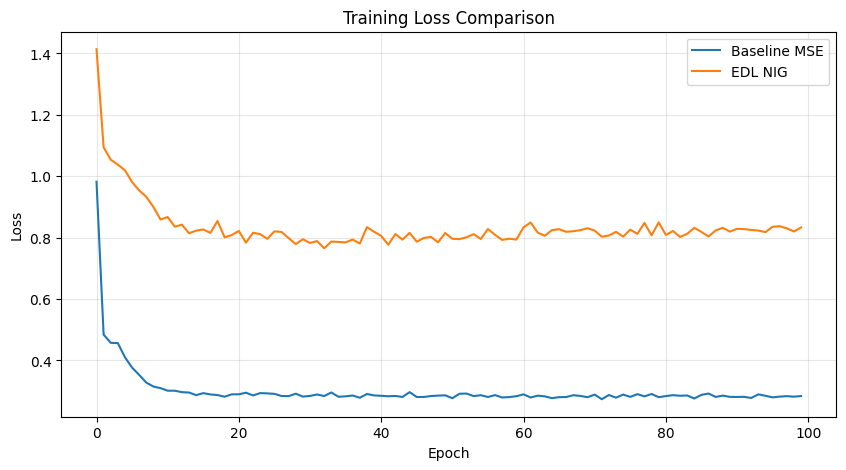

In [26]:
# Plot training losses
plt.figure(figsize=(10, 5))
plt.plot(losses, label='Baseline MSE')
plt.plot(edl_losses, label='EDL NIG')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Comparison')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Visualize EDL Predictions with Uncertainty

The model outputs both predictions and uncertainty estimates. Notice how uncertainty increases in out-of-distribution regions.

In [27]:
def extract_nig_params(outputs):
    """
    Extract NIG parameters from network outputs.
    Returns: gamma (mean), aleatoric_std, epistemic_std, total_std
    """
    gamma, nu, alpha, beta = outputs
    
    # Aleatoric uncertainty (data noise)
    aleatoric_var = beta / alpha
    
    # Epistemic uncertainty (model uncertainty)
    epistemic_var = beta / (nu * (alpha - 1))
    
    # Total uncertainty
    total_var = aleatoric_var + epistemic_var
    
    return gamma, torch.sqrt(aleatoric_var), torch.sqrt(epistemic_var), torch.sqrt(total_var)


# Evaluate EDL model
model_edl.eval()
x_plot = torch.linspace(-5, 5, 500).unsqueeze(1).to(device)

with torch.no_grad():
    outputs = model_edl(x_plot)
    gamma, ale_std, epi_std, total_std = extract_nig_params(outputs)
    
    gamma = gamma.cpu().numpy()
    ale_std = ale_std.cpu().numpy()
    epi_std = epi_std.cpu().numpy()
    total_std = total_std.cpu().numpy()

x_plot_np = x_plot.cpu().numpy()

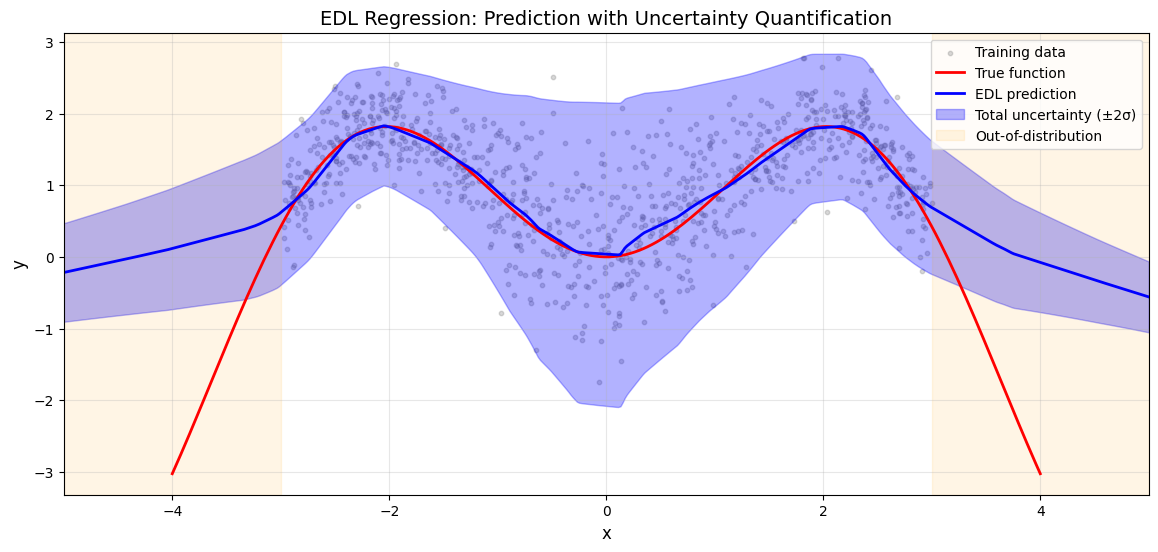

In [28]:
# Plot EDL predictions with uncertainty bands
plt.figure(figsize=(14, 6))

plt.scatter(x_train, y_train, alpha=0.3, s=10, label='Training data', color='gray')
plt.plot(x_true, y_true, 'r-', linewidth=2, label='True function')
plt.plot(x_plot_np, gamma, 'b-', linewidth=2, label='EDL prediction')

# 2-sigma uncertainty bands
plt.fill_between(x_plot_np.flatten(), 
                 (gamma - 2*total_std).flatten(), 
                 (gamma + 2*total_std).flatten(), 
                 alpha=0.3, color='blue', label='Total uncertainty (±2σ)')

plt.axvspan(-5, -3, alpha=0.1, color='orange', label='Out-of-distribution')
plt.axvspan(3, 5, alpha=0.1, color='orange')

plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('EDL Regression: Prediction with Uncertainty Quantification', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(-5, 5)
plt.show()

## Decompose Uncertainty: Aleatoric vs Epistemic

- **Aleatoric**: Irreducible data noise (constant across x)
- **Epistemic**: Model uncertainty (high in OOD regions)
- **Total**: Sum of both

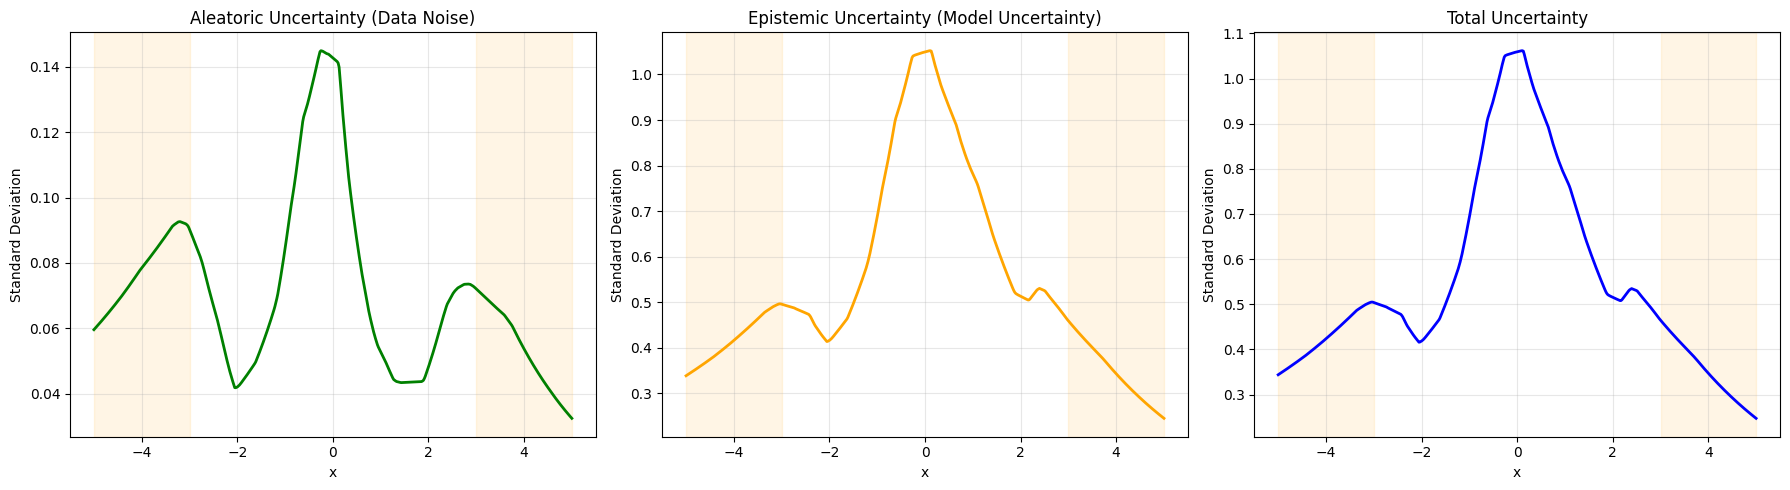

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Aleatoric uncertainty
axes[0].plot(x_plot_np, ale_std, 'g-', linewidth=2)
axes[0].axvspan(-5, -3, alpha=0.1, color='orange')
axes[0].axvspan(3, 5, alpha=0.1, color='orange')
axes[0].set_xlabel('x')
axes[0].set_ylabel('Standard Deviation')
axes[0].set_title('Aleatoric Uncertainty (Data Noise)')
axes[0].grid(alpha=0.3)

# Epistemic uncertainty
axes[1].plot(x_plot_np, epi_std, 'orange', linewidth=2)
axes[1].axvspan(-5, -3, alpha=0.1, color='orange')
axes[1].axvspan(3, 5, alpha=0.1, color='orange')
axes[1].set_xlabel('x')
axes[1].set_ylabel('Standard Deviation')
axes[1].set_title('Epistemic Uncertainty (Model Uncertainty)')
axes[1].grid(alpha=0.3)

# Total uncertainty
axes[2].plot(x_plot_np, total_std, 'b-', linewidth=2)
axes[2].axvspan(-5, -3, alpha=0.1, color='orange')
axes[2].axvspan(3, 5, alpha=0.1, color='orange')
axes[2].set_xlabel('x')
axes[2].set_ylabel('Standard Deviation')
axes[2].set_title('Total Uncertainty')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Key Observations

1. **In-distribution (|x| < 3)**: Low epistemic uncertainty, model is confident
2. **Out-of-distribution (|x| > 3)**: High epistemic uncertainty, model knows it doesn't know
3. **Aleatoric uncertainty**: Relatively constant, captures inherent data noise
4. **Total uncertainty**: Increases dramatically in OOD regions

This demonstrates EDL's ability to provide reliable uncertainty estimates for regression tasks!

## Compare Baseline vs EDL on OOD Data

In [30]:
# Test on specific OOD points
ood_points = torch.tensor([[-4.5], [-4.0], [4.0], [4.5]]).to(device)

model_baseline.eval()
model_edl.eval()

with torch.no_grad():
    # Baseline predictions (no uncertainty)
    baseline_preds = model_baseline(ood_points).cpu().numpy()
    
    # EDL predictions (with uncertainty)
    edl_outputs = model_edl(ood_points)
    edl_mean, _, edl_epi, edl_total = extract_nig_params(edl_outputs)
    edl_mean = edl_mean.cpu().numpy()
    edl_total = edl_total.cpu().numpy()

# Display results
print("Out-of-Distribution Predictions:\n")
print(f"{'x':<8} {'True y':<12} {'Baseline':<12} {'EDL Mean':<12} {'EDL Unc (±2σ)':<15}")
print("-" * 70)

for i, x_val in enumerate(ood_points.cpu().numpy()):
    true_y = x_val[0] * np.sin(x_val[0])
    baseline_y = baseline_preds[i, 0]
    edl_y = edl_mean[i, 0]
    edl_unc = 2 * edl_total[i, 0]
    
    print(f"{x_val[0]:<8.2f} {true_y:<12.3f} {baseline_y:<12.3f} {edl_y:<12.3f} ±{edl_unc:<12.3f}")

Out-of-Distribution Predictions:

x        True y       Baseline     EDL Mean     EDL Unc (±2σ)  
----------------------------------------------------------------------
-4.50    -4.399       0.341        -0.055       ±0.761       
-4.00    -3.027       0.373        0.117        ±0.847       
4.00     -3.027       -0.015       -0.077       ±0.695       
4.50     -4.399       -0.141       -0.322       ±0.586       


## Summary

**EDL for Regression provides:**
- Accurate predictions on in-distribution data
- Uncertainty quantification (know when the model doesn't know)
- Decomposition into aleatoric and epistemic uncertainty
- High uncertainty in out-of-distribution regions

**Key difference from baseline:**
- Traditional regression: single point estimate
- EDL regression: distribution over predictions with uncertainty bounds

This makes EDL ideal for safety-critical applications where knowing model confidence is essential!